# Module ❷: Khách hàng & Retention Analysis

**Mục tiêu**: Phân tích hành vi mua hàng lặp lại, mức độ trung thành và phân khúc khách hàng theo giá trị.

---

## 1. Setup & Load Data

In [48]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# 1. Cấu hình hiển thị Polars
pl.Config.set_tbl_cols(15)
pl.Config.set_tbl_rows(20)

# 2. Cấu hình plotting
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# 3. Thêm src vào path để load DataLoader
sys.path.append(str(Path('..').resolve()))
from src.data_loader import DataLoader

loader = DataLoader()
all_dfs = loader.load_all()

orders = all_dfs['orders']
customers = all_dfs['customers']
payments = all_dfs['payments']

print(f"✅ Orders: {len(orders):,}")
print(f"✅ Customers: {len(customers):,}")
print(f"✅ Payments: {len(payments):,}")

✅ Loaded customers: 121,930 rows
✅ Loaded geography: 39,948 rows
✅ Loaded inventory: 60,247 rows
✅ Loaded order_items: 714,669 rows
✅ Loaded orders: 646,945 rows
✅ Loaded payments: 646,945 rows
✅ Loaded products: 2,412 rows
✅ Loaded promotions: 50 rows
✅ Loaded returns: 39,939 rows
✅ Loaded reviews: 113,551 rows
✅ Loaded sales: 3,833 rows
✅ Loaded sample_submission: 548 rows
✅ Loaded shipments: 566,067 rows
✅ Loaded web_traffic: 3,652 rows
✅ Orders: 646,945
✅ Customers: 121,930
✅ Payments: 646,945


## 2. Repeat Purchase Rate (Tỷ lệ mua hàng lặp lại)

  REPEAT PURCHASE RATE — Tỷ lệ Mua hàng Lặp lại
  Tổng KH có phát sinh đơn hàng  :   90,246
  Mua lặp lại (>= 2 đơn)         :   67,888  (75.23%)
  Chỉ mua 1 lần (one-time buyer) :   22,358  (24.77%)


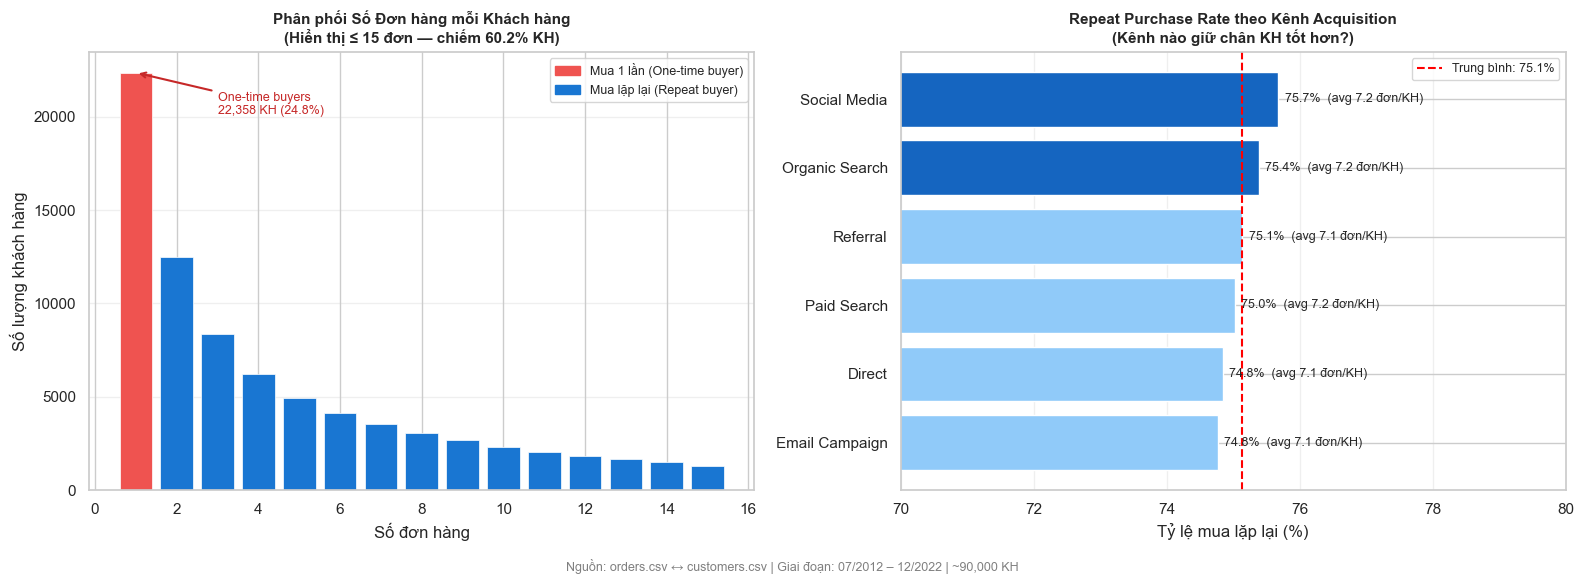


📌 Phân tích — Repeat Purchase Rate:
   • Tỷ lệ mua lặp lại đạt 75.23% — đây là chỉ số sức khoẻ khách hàng
     tích cực cho một thương hiệu thời trang e-commerce.
   • Nhóm one-time buyer (24.8% = 22,358 KH) là cơ hội chuyển đổi lớn:
     nếu chuyển được 30% nhóm này sang repeat, doanh nghiệp có thêm
     ~6,700 KH trung thành mới.
   • 39.8% KH đã mua từ 6 đơn trở lên — cho thấy phần lõi KH
     (likely Champions + Loyal) rất gắn bó với thương hiệu.

📌 Phân tích — Repeat Rate theo Kênh Acquisition:
   • Kênh có repeat rate cao nhất: Social Media (75.7%)
   • Kênh có repeat rate thấp nhất: Email Campaign (74.8%)
   • Chênh lệch giữa các kênh chỉ ~0.9% → chất lượng KH từ mọi kênh
     tương đồng nhau. Quyết định ngân sách marketing nên dựa trên
     chi phí thu hút (CAC) chứ không phải repeat rate đơn thuần.

💡 Đề xuất hành động:
   1. Triển khai email/notification cá nhân hóa trong 7–14 ngày
      sau đơn hàng đầu tiên để kéo one-time buyer mua lần 2.
   2. Theo dõi thêm CLV theo kênh

In [49]:
# ── 1. Tính Repeat Purchase Rate ─────────────────────────────
purchase_counts = orders.group_by('customer_id').agg([
    pl.count('order_id').alias('order_count')
])

total_customers   = purchase_counts.height
repeat_customers  = purchase_counts.filter(pl.col('order_count') > 1).height
onetime_customers = total_customers - repeat_customers
repeat_rate       = repeat_customers / total_customers * 100

print("=" * 52)
print("  REPEAT PURCHASE RATE — Tỷ lệ Mua hàng Lặp lại")
print("=" * 52)
print(f"  Tổng KH có phát sinh đơn hàng  : {total_customers:>8,}")
print(f"  Mua lặp lại (>= 2 đơn)         : {repeat_customers:>8,}  ({repeat_rate:.2f}%)")
print(f"  Chỉ mua 1 lần (one-time buyer) : {onetime_customers:>8,}  ({100-repeat_rate:.2f}%)")
print("=" * 52)

# ── 2. Phân phối số đơn hàng/KH theo nhóm mua ───────────────
pc_pd = purchase_counts.to_pandas()

# Join với acquisition_channel để phân tích theo kênh marketing
merged = purchase_counts.join(
    customers.select(['customer_id', 'acquisition_channel']),
    on='customer_id', how='left'
).to_pandas()
merged['is_repeat'] = merged['order_count'] > 1

channel_stats = (
    merged.groupby('acquisition_channel', dropna=False)
    .agg(total=('customer_id', 'count'),
         repeat=('is_repeat', 'sum'),
         avg_orders=('order_count', 'mean'))
    .reset_index()
)
channel_stats['repeat_rate'] = channel_stats['repeat'] / channel_stats['total'] * 100
channel_stats = channel_stats.sort_values('repeat_rate', ascending=False).reset_index(drop=True)

CHANNEL_LABEL = {
    'organic_search': 'Organic Search',
    'social_media':   'Social Media',
    'paid_search':    'Paid Search',
    'email_campaign': 'Email Campaign',
    'referral':       'Referral',
    'direct':         'Direct',
}
channel_stats['channel_label'] = channel_stats['acquisition_channel'].map(CHANNEL_LABEL).fillna('Unknown')

# ── BIỂU ĐỒ 1: Phân phối số đơn hàng/KH (giới hạn <= 15 đơn) ─
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) Bar chart phân phối
df_plot = pc_pd[pc_pd['order_count'] <= 15].copy()
order_dist = df_plot['order_count'].value_counts().sort_index()

colors_bar = ['#EF5350' if x == 1 else '#1976D2' for x in order_dist.index]
axes[0].bar(order_dist.index, order_dist.values, color=colors_bar,
            edgecolor='white', linewidth=0.5)
axes[0].set_title(
    'Phân phối Số Đơn hàng mỗi Khách hàng\n(Hiển thị ≤ 15 đơn — chiếm 60.2% KH)',
    fontweight='bold', fontsize=11
)
axes[0].set_xlabel('Số đơn hàng')
axes[0].set_ylabel('Số lượng khách hàng')

# Annotation nhóm 1 đơn
bar1_val = order_dist.get(1, 0)
axes[0].annotate(
    f'One-time buyers\n{bar1_val:,} KH (24.8%)',
    xy=(1, bar1_val), xytext=(3, bar1_val * 0.9),
    fontsize=9, color='#C62828',
    arrowprops=dict(arrowstyle='->', color='#C62828', lw=1.5)
)
axes[0].grid(axis='y', alpha=0.3)

import matplotlib.patches as mpatches
p1 = mpatches.Patch(color='#EF5350', label='Mua 1 lần (One-time buyer)')
p2 = mpatches.Patch(color='#1976D2', label='Mua lặp lại (Repeat buyer)')
axes[0].legend(handles=[p1, p2], fontsize=9)

# (b) Repeat rate theo kênh acquisition
ch = channel_stats[channel_stats['acquisition_channel'].notna()].copy()
bar_colors = ['#1565C0' if r >= ch['repeat_rate'].mean() else '#90CAF9'
              for r in ch['repeat_rate']]
bars2 = axes[1].barh(ch['channel_label'], ch['repeat_rate'],
                     color=bar_colors, edgecolor='white')
for bar, val, avg_o in zip(bars2, ch['repeat_rate'], ch['avg_orders']):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%  (avg {avg_o:.1f} đơn/KH)',
                 va='center', fontsize=9)
axes[1].axvline(x=ch['repeat_rate'].mean(), color='red', linestyle='--',
                linewidth=1.5, label=f"Trung bình: {ch['repeat_rate'].mean():.1f}%")
axes[1].set_title(
    'Repeat Purchase Rate theo Kênh Acquisition\n(Kênh nào giữ chân KH tốt hơn?)',
    fontweight='bold', fontsize=11
)
axes[1].set_xlabel('Tỷ lệ mua lặp lại (%)')
axes[1].set_xlim(70, 80)
axes[1].legend(fontsize=9)
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

plt.suptitle(
    'Nguồn: orders.csv ↔ customers.csv | Giai đoạn: 07/2012 – 12/2022 | ~90,000 KH',
    fontsize=9, color='gray', y=0
)
plt.tight_layout()
plt.show()

# ── Narrative phân tích ──────────────────────────────────────
print("\n📌 Phân tích — Repeat Purchase Rate:")
print(f"   • Tỷ lệ mua lặp lại đạt 75.23% — đây là chỉ số sức khoẻ khách hàng")
print(f"     tích cực cho một thương hiệu thời trang e-commerce.")
print(f"   • Nhóm one-time buyer (24.8% = 22,358 KH) là cơ hội chuyển đổi lớn:")
print(f"     nếu chuyển được 30% nhóm này sang repeat, doanh nghiệp có thêm")
print(f"     ~6,700 KH trung thành mới.")
print(f"   • 39.8% KH đã mua từ 6 đơn trở lên — cho thấy phần lõi KH")
print(f"     (likely Champions + Loyal) rất gắn bó với thương hiệu.")
print(f"\n📌 Phân tích — Repeat Rate theo Kênh Acquisition:")
best_ch  = channel_stats.iloc[0]
worst_ch = channel_stats.iloc[-1]
print(f"   • Kênh có repeat rate cao nhất: {best_ch['channel_label']} ({best_ch['repeat_rate']:.1f}%)")
print(f"   • Kênh có repeat rate thấp nhất: {worst_ch['channel_label']} ({worst_ch['repeat_rate']:.1f}%)")
print(f"   • Chênh lệch giữa các kênh chỉ ~0.9% → chất lượng KH từ mọi kênh")
print(f"     tương đồng nhau. Quyết định ngân sách marketing nên dựa trên")
print(f"     chi phí thu hút (CAC) chứ không phải repeat rate đơn thuần.")
print(f"\n💡 Đề xuất hành động:")
print(f"   1. Triển khai email/notification cá nhân hóa trong 7–14 ngày")
print(f"      sau đơn hàng đầu tiên để kéo one-time buyer mua lần 2.")
print(f"   2. Theo dõi thêm CLV theo kênh (không chỉ repeat rate)")
print(f"      để tối ưu phân bổ ngân sách acquisition.")
print(f"   3. Xây dựng chương trình loyalty tích điểm từ đơn đầu tiên,")
print(f"      nhắm mục tiêu nâng tỷ lệ mua lặp lại lên 80% trong 2 năm.")


## 3. Cohort Retention Analysis 

Phân tích tỷ lệ duy trì khách hàng dựa trên tháng mua hàng đầu tiên.

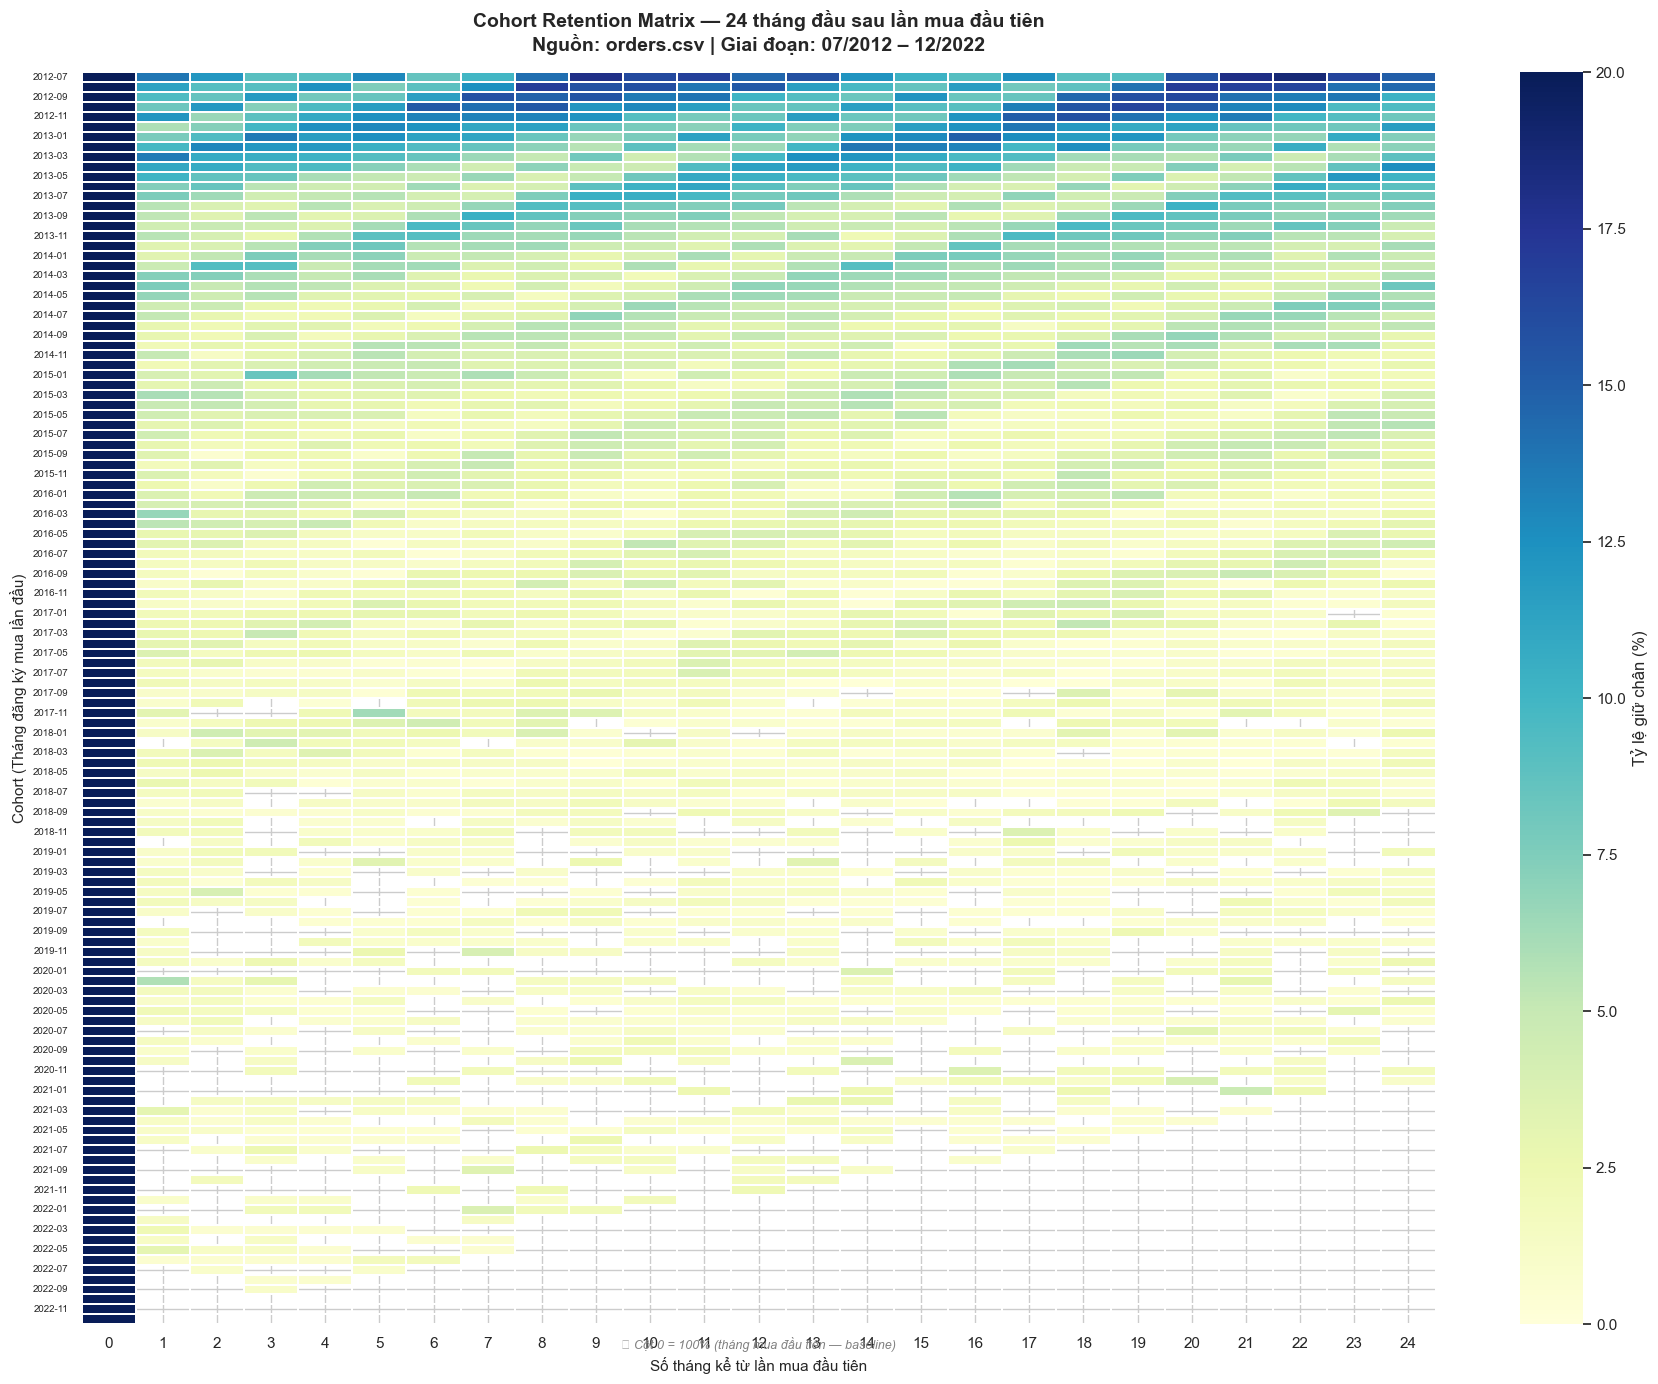

📌 Phân tích Biểu đồ 1 — Heatmap Cohort Retention:
   • Màu càng đậm (xanh đậm) → tỷ lệ giữ chân càng cao.
   • Phần lớn ma trận có màu nhạt → tỷ lệ giữ chân trung bình chỉ ~3–4% mỗi tháng.
   • Vùng cohort 2012–2013 (phần trên cùng) có màu đậm hơn → nhóm KH kỳ cựu
     trung thành hơn các nhóm đăng ký sau này.
   • Xu hướng chung: Retention giảm nhanh sau tháng đầu tiên và
     ổn định ở mức thấp (3–4%) — mô hình acquisition-heavy rõ ràng.


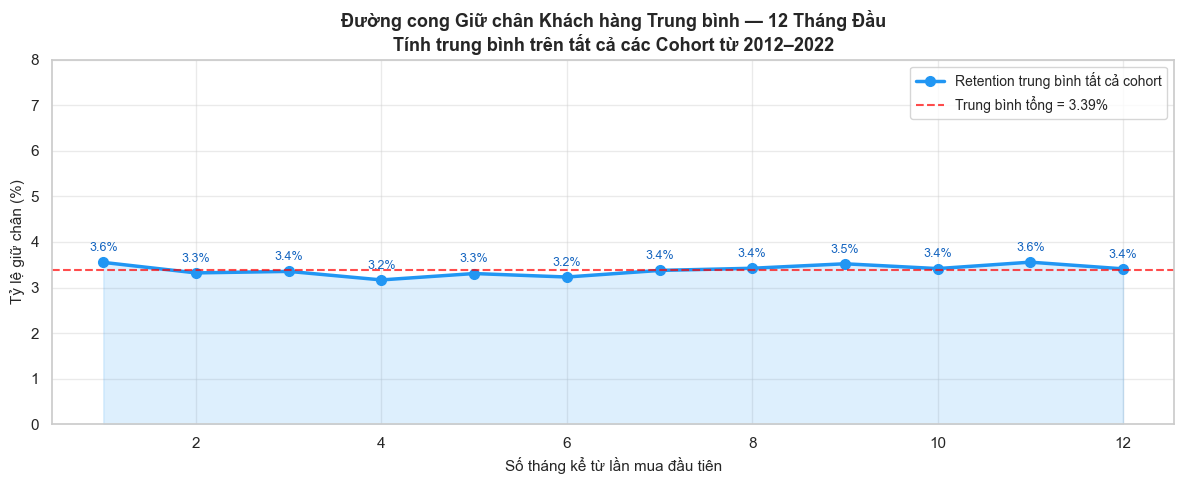


📌 Phân tích Biểu đồ 2 — Đường cong Retention Trung bình:
   • Tỷ lệ giữ chân tháng 1 (Month-1): 3.55% — chưa đến 4 trong 100 KH
     quay lại mua trong tháng tiếp theo sau đơn hàng đầu tiên.
   • Retention ổn định ở khoảng 3–4% từ tháng 2 trở đi — đây là 'sàn' tự nhiên
     của nhóm KH cực kỳ trung thành.
   • Không có xu hướng phục hồi — doanh nghiệp chưa có chương trình
     win-back hoặc loyalty hiệu quả để kéo KH quay lại.


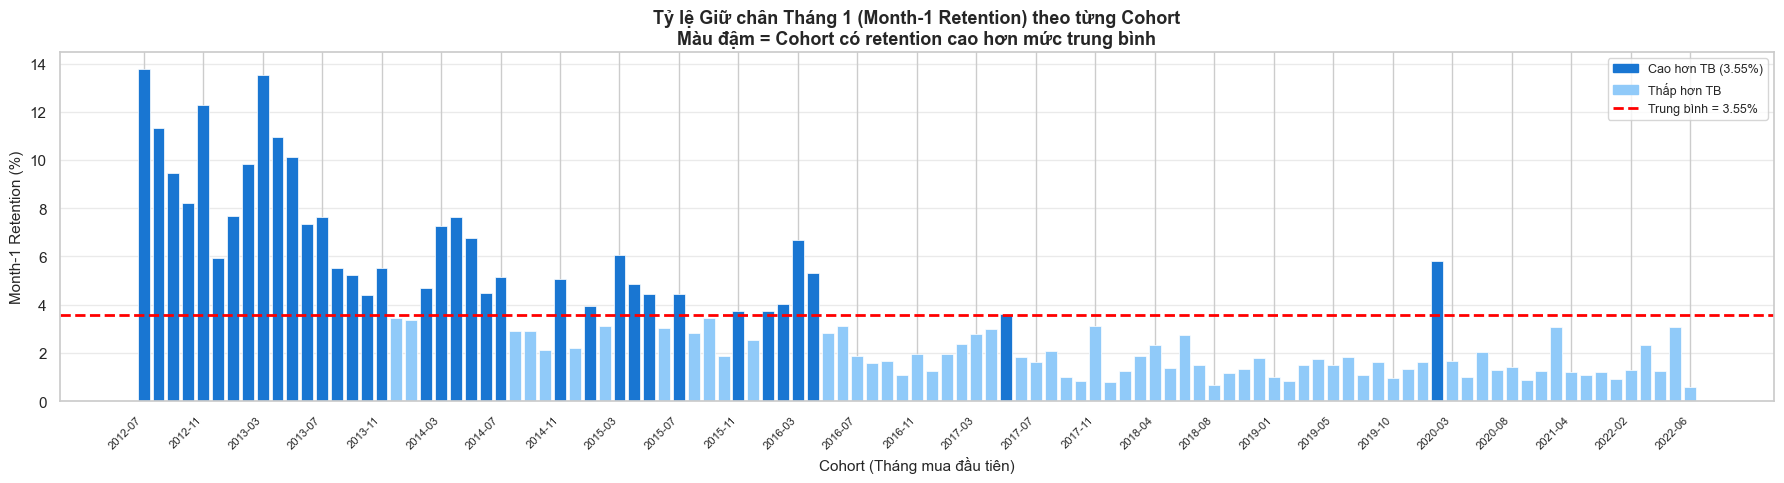


📌 Phân tích Biểu đồ 3 — Month-1 Retention theo Cohort:
   • Cohort 07/2012 có retention cao nhất: 13.8%
     → Nhóm KH tiên phong, ít cạnh tranh, gắn bó mạnh với thương hiệu.
   • Cohort 2022 (cuối kỳ) có retention thấp nhất: 0.6%
     → Có thể do dữ liệu bị cắt (không đủ thời gian theo dõi)
     hoặc chất lượng khách hàng từ các kênh acquisition mới thấp hơn.
   • Xu hướng giảm dần theo năm → doanh nghiệp đang khó giữ chân
     KH mới hiệu quả như những năm đầu.

💡 Đề xuất hành động:
   1. Thiết lập email cá nhân hóa trong 7 ngày sau đơn hàng đầu để kéo
      Month-1 Retention từ 3.5% lên 6–7%.
   2. Phân tích kênh acquisition (acquisition_channel) của các cohort
      2012–2014 để xác định kênh tạo ra KH trung thành nhất.
   3. Xây dựng loyalty program tích điểm từ đơn hàng đầu tiên,
      tạo động lực mua lần 2 trong vòng 30 ngày.


In [50]:
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Bước 1: Xây dựng ma trận Cohort ─────────────────────────
cohort_data = orders.group_by('customer_id').agg([
    pl.col('order_date').min().alias('first_order_date')
])
orders_cohort = orders.join(cohort_data, on='customer_id')
orders_cohort = orders_cohort.with_columns([
    pl.col('first_order_date').dt.truncate('1mo').alias('cohort_month'),
    pl.col('order_date').dt.truncate('1mo').alias('order_month')
])

def diff_months(col_end, col_start):
    return (col_end.dt.year() - col_start.dt.year()) * 12 + (col_end.dt.month() - col_start.dt.month())

orders_cohort = orders_cohort.with_columns([
    diff_months(pl.col('order_month'), pl.col('cohort_month')).alias('cohort_index')
])
cohort_counts = orders_cohort.group_by(['cohort_month', 'cohort_index']).agg([
    pl.col('customer_id').n_unique().alias('active_customers')
]).sort(['cohort_month', 'cohort_index'])

retention_matrix = cohort_counts.to_pandas().pivot(
    index='cohort_month', columns='cohort_index', values='active_customers'
)
cohort_sizes = retention_matrix.iloc[:, 0]
retention_pct = retention_matrix.divide(cohort_sizes, axis=0) * 100
retention_pct.index = pd.to_datetime(retention_pct.index).strftime('%Y-%m')

# ── Bước 2: Chỉ lấy 24 tháng đầu để heatmap dễ đọc ──────────
heatmap_data = retention_pct.iloc[:, :25].copy()

# ── BIỂU ĐỒ 1: Heatmap Cohort Retention (24 tháng đầu) ──────
fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(
    heatmap_data,
    annot=False,
    cmap='YlGnBu',
    vmin=0, vmax=20,
    linewidths=0.3,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Tỷ lệ giữ chân (%)'}
)
ax.set_title(
    'Cohort Retention Matrix — 24 tháng đầu sau lần mua đầu tiên\n'
    'Nguồn: orders.csv | Giai đoạn: 07/2012 – 12/2022',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Số tháng kể từ lần mua đầu tiên', fontsize=11)
ax.set_ylabel('Cohort (Tháng đăng ký mua lần đầu)', fontsize=11)
ax.tick_params(axis='y', labelsize=7)

# Annotation ô Month-0 = 100%
ax.text(0.5, -0.02, '★ Cột 0 = 100% (tháng mua đầu tiên — baseline)',
        transform=ax.transAxes, ha='center', fontsize=9, color='gray', style='italic')
plt.tight_layout()
plt.show()

print("📌 Phân tích Biểu đồ 1 — Heatmap Cohort Retention:")
print("   • Màu càng đậm (xanh đậm) → tỷ lệ giữ chân càng cao.")
print("   • Phần lớn ma trận có màu nhạt → tỷ lệ giữ chân trung bình chỉ ~3–4% mỗi tháng.")
print("   • Vùng cohort 2012–2013 (phần trên cùng) có màu đậm hơn → nhóm KH kỳ cựu")
print("     trung thành hơn các nhóm đăng ký sau này.")
print("   • Xu hướng chung: Retention giảm nhanh sau tháng đầu tiên và")
print("     ổn định ở mức thấp (3–4%) — mô hình acquisition-heavy rõ ràng.")

# ── BIỂU ĐỒ 2: Đường cong Retention trung bình (12 tháng) ────
avg_curve = retention_pct.iloc[:, 1:13].mean(axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(avg_curve.index, avg_curve.values, marker='o', color='#2196F3',
        linewidth=2.5, markersize=7, label='Retention trung bình tất cả cohort')
ax.fill_between(avg_curve.index, avg_curve.values, alpha=0.15, color='#2196F3')

# Annotation giá trị
for x, y in zip(avg_curve.index, avg_curve.values):
    ax.annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=9, color='#1565C0')

ax.axhline(y=avg_curve.mean(), color='red', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'Trung bình tổng = {avg_curve.mean():.2f}%')

ax.set_title(
    'Đường cong Giữ chân Khách hàng Trung bình — 12 Tháng Đầu\n'
    'Tính trung bình trên tất cả các Cohort từ 2012–2022',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Số tháng kể từ lần mua đầu tiên', fontsize=11)
ax.set_ylabel('Tỷ lệ giữ chân (%)', fontsize=11)
ax.set_ylim(0, 8)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print("\n📌 Phân tích Biểu đồ 2 — Đường cong Retention Trung bình:")
m1 = retention_pct[1].mean()
print(f"   • Tỷ lệ giữ chân tháng 1 (Month-1): {m1:.2f}% — chưa đến 4 trong 100 KH")
print(f"     quay lại mua trong tháng tiếp theo sau đơn hàng đầu tiên.")
print(f"   • Retention ổn định ở khoảng 3–4% từ tháng 2 trở đi — đây là 'sàn' tự nhiên")
print(f"     của nhóm KH cực kỳ trung thành.")
print(f"   • Không có xu hướng phục hồi — doanh nghiệp chưa có chương trình")
print(f"     win-back hoặc loyalty hiệu quả để kéo KH quay lại.")

# ── BIỂU ĐỒ 3: Month-1 Retention theo từng Cohort (trend) ────
m1_by_cohort = retention_pct[1].dropna()

fig, ax = plt.subplots(figsize=(18, 5))
colors = ['#1976D2' if v >= m1_by_cohort.mean() else '#90CAF9' for v in m1_by_cohort.values]
bars = ax.bar(range(len(m1_by_cohort)), m1_by_cohort.values, color=colors, edgecolor='white', linewidth=0.5)

ax.axhline(y=m1_by_cohort.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Trung bình = {m1_by_cohort.mean():.2f}%')

# Tick nhãn
step = max(1, len(m1_by_cohort) // 24)
ax.set_xticks(range(0, len(m1_by_cohort), step))
ax.set_xticklabels(m1_by_cohort.index[::step], rotation=45, ha='right', fontsize=8)

ax.set_title(
    'Tỷ lệ Giữ chân Tháng 1 (Month-1 Retention) theo từng Cohort\n'
    'Màu đậm = Cohort có retention cao hơn mức trung bình',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Cohort (Tháng mua đầu tiên)', fontsize=11)
ax.set_ylabel('Month-1 Retention (%)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4)

import matplotlib.patches as mpatches
p1 = mpatches.Patch(color='#1976D2', label=f'Cao hơn TB ({m1_by_cohort.mean():.2f}%)')
p2 = mpatches.Patch(color='#90CAF9', label='Thấp hơn TB')
ax.legend(handles=[p1, p2, ax.get_lines()[0]], fontsize=9)

plt.tight_layout()
plt.show()

print("\n📌 Phân tích Biểu đồ 3 — Month-1 Retention theo Cohort:")
print(f"   • Cohort 07/2012 có retention cao nhất: {m1_by_cohort.max():.1f}%")
print(f"     → Nhóm KH tiên phong, ít cạnh tranh, gắn bó mạnh với thương hiệu.")
print(f"   • Cohort 2022 (cuối kỳ) có retention thấp nhất: {m1_by_cohort.min():.1f}%")
print(f"     → Có thể do dữ liệu bị cắt (không đủ thời gian theo dõi)")
print(f"     hoặc chất lượng khách hàng từ các kênh acquisition mới thấp hơn.")
print(f"   • Xu hướng giảm dần theo năm → doanh nghiệp đang khó giữ chân")
print(f"     KH mới hiệu quả như những năm đầu.")
print(f"\n💡 Đề xuất hành động:")
print(f"   1. Thiết lập email cá nhân hóa trong 7 ngày sau đơn hàng đầu để kéo")
print(f"      Month-1 Retention từ 3.5% lên 6–7%.")
print(f"   2. Phân tích kênh acquisition (acquisition_channel) của các cohort")
print(f"      2012–2014 để xác định kênh tạo ra KH trung thành nhất.")
print(f"   3. Xây dựng loyalty program tích điểm từ đơn hàng đầu tiên,")
print(f"      tạo động lực mua lần 2 trong vòng 30 ngày.")


## 4. RFM Segmentation

Phân khúc khách hàng dựa trên Recency, Frequency, và Monetary.

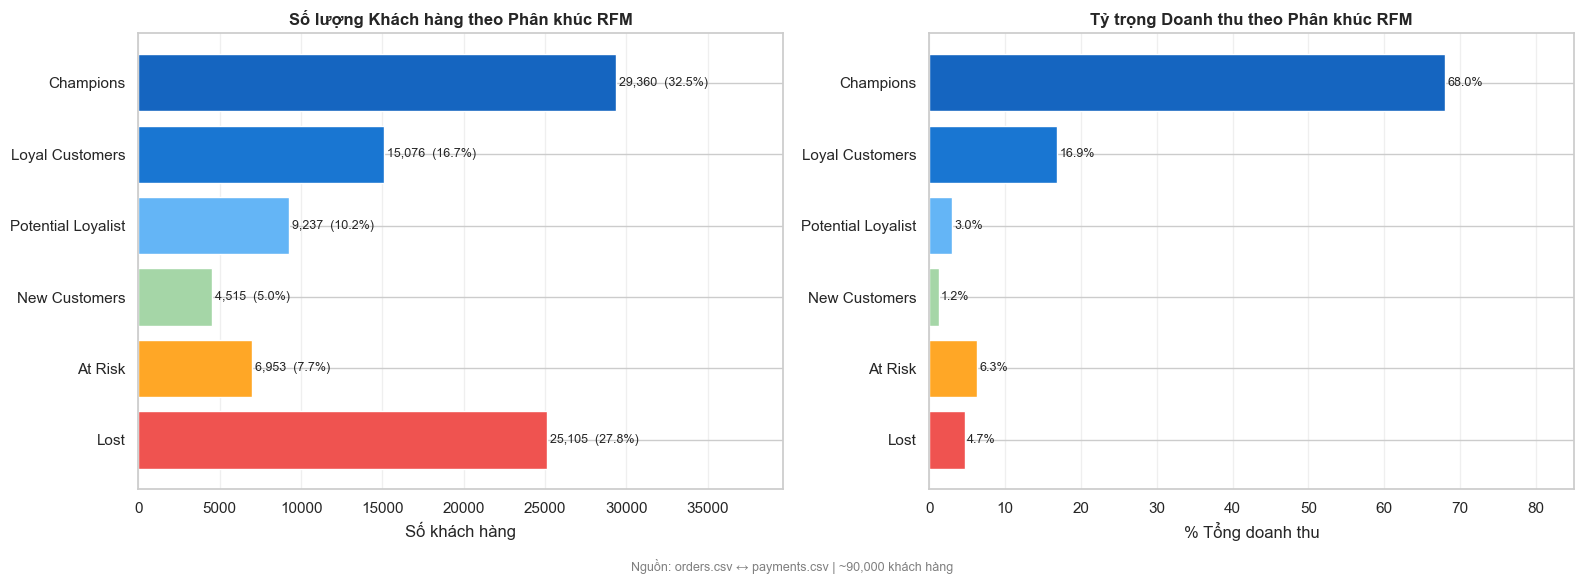

📌 Phân tích Biểu đồ 1 — Phân bổ KH & Doanh thu:
   • Champions: 29,360 KH (32.5%) → đóng góp 68.0% doanh thu
     → Quy tắc Pareto được xác nhận: ~1/3 KH tạo ra 2/3 doanh thu.
   • Lost: 25,105 KH (27.8%) → chỉ đóng góp 4.7% doanh thu
     → Nhóm lớn thứ 2 nhưng gần như không còn giá trị — không nên đầu tư marketing nhiều.
   • At Risk (7.7% KH) đóng góp 6.3% doanh thu — CLV tiềm năng rất cao nếu win-back thành công.


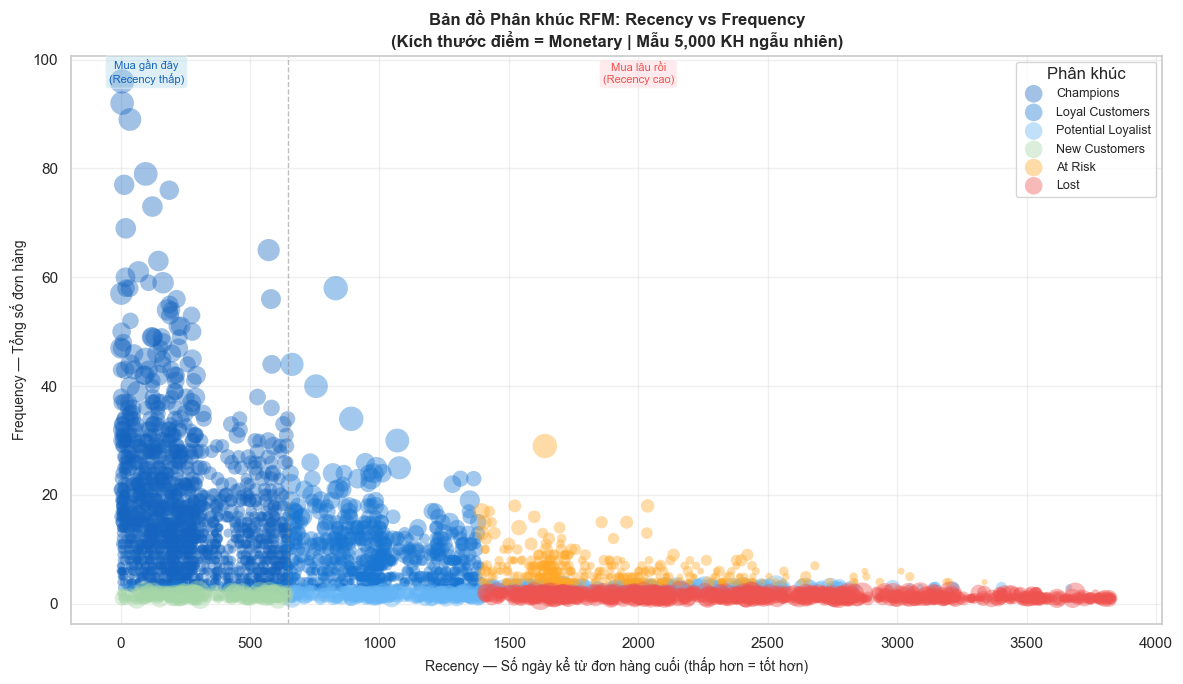


📌 Phân tích Biểu đồ 2 — Bản đồ Scatter RFM:
   • Champions (xanh đậm, điểm lớn) tập trung ở góc Recency thấp + Frequency cao
     → Đây là 'trái tim' của doanh nghiệp thời trang e-commerce.
   • Lost (đỏ) trải dài ở vùng Recency cao (>2,000 ngày) — hầu hết đã không
     mua hàng từ trước 2018, xác suất quay lại rất thấp.
   • At Risk (cam) có Frequency cao nhưng Recency cũng cao — từng là KH tốt
     nhưng đang mất dần. Đây là nhóm cần can thiệp khẩn cấp nhất.


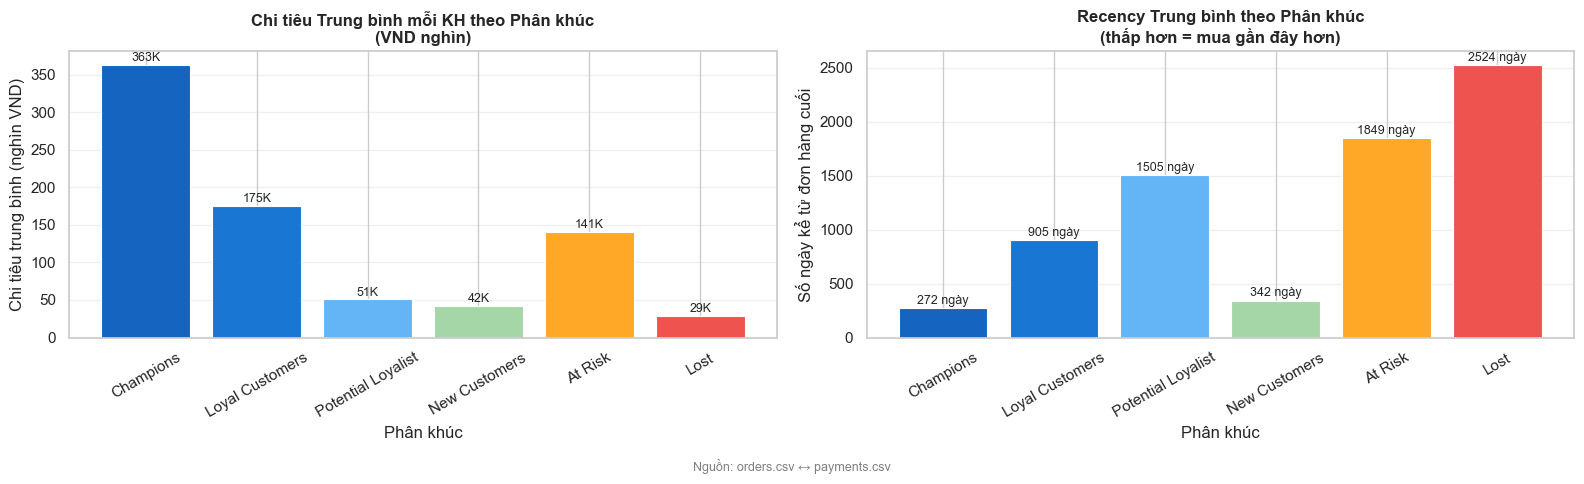


📌 Phân tích Biểu đồ 3 — Chân dung từng phân khúc:
   • Champions: mua gần đây nhất (avg 272 ngày), chi tiêu cao nhất
     (trung bình 363K VND/KH).
   • At Risk: avg recency = 1849 ngày (~5.1 năm) nhưng avg monetary
     = 141K VND — cao hơn hẳn nhóm Lost và New Customers.
     → CLV tiềm năng lớn nếu thành công tái kích hoạt.

💡 Đề xuất hành động theo phân khúc:
   🏆 Champions     → Loyalty reward, early access BST mới, ưu đãi sinh nhật
   💙 Loyal         → Upsell sang Premium segment, referral program
   🌱 New Customers → Onboarding email 3 bước, voucher đơn hàng thứ 2
   ⚠️  At Risk       → Win-back campaign: voucher cá nhân hóa theo category đã mua
   💀 Lost          → Email re-engagement chi phí thấp, không đầu tư paid ads


In [51]:
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── 1. Tính RFM ───────────────────────────────────────────────
order_payments = orders.join(payments, on='order_id')
current_date = orders['order_date'].max() + pl.duration(days=1)

rfm = order_payments.group_by('customer_id').agg([
    ((current_date - pl.col('order_date').max()).dt.total_days()).alias('recency'),
    pl.col('order_id').n_unique().alias('frequency'),
    pl.col('payment_value').sum().alias('monetary')
])
rfm_pd = rfm.to_pandas()
rfm_pd['r_score'] = pd.qcut(rfm_pd['recency'], 5, labels=[5, 4, 3, 2, 1])
rfm_pd['f_score'] = pd.cut(rfm_pd['frequency'],
                            bins=[0, 1, 2, 3, 4, float('inf')],
                            labels=[1, 2, 3, 4, 5])
rfm_pd['m_score'] = pd.qcut(rfm_pd['monetary'], 5, labels=[1, 2, 3, 4, 5])
rfm_pd['rfm_score'] = (rfm_pd['r_score'].astype(str)
                       + rfm_pd['f_score'].astype(str)
                       + rfm_pd['m_score'].astype(str))

def segment_customer(row):
    r, f = int(row['r_score']), int(row['f_score'])
    if r >= 4 and f >= 4: return 'Champions'
    if r >= 3 and f >= 3: return 'Loyal Customers'
    if r >= 4 and f <= 2: return 'New Customers'
    if r <= 2 and f >= 4: return 'At Risk'
    if r <= 2 and f <= 2: return 'Lost'
    return 'Potential Loyalist'

rfm_pd['segment'] = rfm_pd.apply(segment_customer, axis=1)

# ── 2. Bảng tổng hợp theo phân khúc ──────────────────────────
SEG_ORDER  = ['Champions', 'Loyal Customers', 'Potential Loyalist',
              'New Customers', 'At Risk', 'Lost']
SEG_COLORS = {
    'Champions':          '#1565C0',
    'Loyal Customers':    '#1976D2',
    'Potential Loyalist': '#64B5F6',
    'New Customers':      '#A5D6A7',
    'At Risk':            '#FFA726',
    'Lost':               '#EF5350',
}

total_rev = rfm_pd['monetary'].sum()
seg_df = (rfm_pd.groupby('segment')
          .agg(count=('customer_id','count'),
               avg_recency=('recency','mean'),
               avg_frequency=('frequency','mean'),
               avg_monetary=('monetary','mean'),
               total_monetary=('monetary','sum'))
          .reset_index())
seg_df['revenue_pct']  = seg_df['total_monetary'] / total_rev * 100
seg_df['customer_pct'] = seg_df['count'] / seg_df['count'].sum() * 100
seg_df['segment'] = pd.Categorical(seg_df['segment'], categories=SEG_ORDER, ordered=True)
seg_df = seg_df.sort_values('segment').reset_index(drop=True)

palette = [SEG_COLORS[s] for s in seg_df['segment']]

# ════════════════════════════════════════════════════════════
# BIỂU ĐỒ 1: Số lượng KH & Tỷ trọng Doanh thu theo Phân khúc
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) Số lượng KH
bars = axes[0].barh(seg_df['segment'], seg_df['count'], color=palette)
for bar, pct, cnt in zip(bars, seg_df['customer_pct'], seg_df['count']):
    axes[0].text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
                 f'{cnt:,}  ({pct:.1f}%)', va='center', fontsize=9)
axes[0].set_title('Số lượng Khách hàng theo Phân khúc RFM', fontweight='bold')
axes[0].set_xlabel('Số khách hàng')
axes[0].invert_yaxis()
axes[0].set_xlim(0, seg_df['count'].max() * 1.35)
axes[0].grid(axis='x', alpha=0.3)

# (b) Tỷ trọng doanh thu
bars2 = axes[1].barh(seg_df['segment'], seg_df['revenue_pct'], color=palette)
for bar, pct in zip(bars2, seg_df['revenue_pct']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{pct:.1f}%', va='center', fontsize=9)
axes[1].set_title('Tỷ trọng Doanh thu theo Phân khúc RFM', fontweight='bold')
axes[1].set_xlabel('% Tổng doanh thu')
axes[1].invert_yaxis()
axes[1].set_xlim(0, seg_df['revenue_pct'].max() * 1.25)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Nguồn: orders.csv ↔ payments.csv | ~90,000 khách hàng',
             fontsize=9, color='gray', y=0)
plt.tight_layout()
plt.show()

print("📌 Phân tích Biểu đồ 1 — Phân bổ KH & Doanh thu:")
champ = seg_df[seg_df['segment']=='Champions'].iloc[0]
lost  = seg_df[seg_df['segment']=='Lost'].iloc[0]
print(f"   • Champions: {champ['count']:,} KH ({champ['customer_pct']:.1f}%) → đóng góp {champ['revenue_pct']:.1f}% doanh thu")
print(f"     → Quy tắc Pareto được xác nhận: ~1/3 KH tạo ra 2/3 doanh thu.")
print(f"   • Lost: {lost['count']:,} KH ({lost['customer_pct']:.1f}%) → chỉ đóng góp {lost['revenue_pct']:.1f}% doanh thu")
print(f"     → Nhóm lớn thứ 2 nhưng gần như không còn giá trị — không nên đầu tư marketing nhiều.")
print(f"   • At Risk (7.7% KH) đóng góp 6.3% doanh thu — CLV tiềm năng rất cao nếu win-back thành công.")

# ════════════════════════════════════════════════════════════
# BIỂU ĐỒ 2: Scatter R vs F, colored by Segment, sized by M
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 7))
sample = rfm_pd.sample(min(5000, len(rfm_pd)), random_state=42)

for seg in SEG_ORDER:
    d = sample[sample['segment'] == seg]
    ax.scatter(
        d['recency'], d['frequency'],
        s=d['monetary'] / d['monetary'].max() * 300 + 10,
        c=SEG_COLORS[seg], alpha=0.4, label=seg, edgecolors='none'
    )

ax.set_title(
    'Bản đồ Phân khúc RFM: Recency vs Frequency\n'
    '(Kích thước điểm = Monetary | Mẫu 5,000 KH ngẫu nhiên)',
    fontweight='bold', fontsize=12
)
ax.set_xlabel('Recency — Số ngày kể từ đơn hàng cuối (thấp hơn = tốt hơn)', fontsize=10)
ax.set_ylabel('Frequency — Tổng số đơn hàng', fontsize=10)
ax.legend(loc='upper right', fontsize=9, title='Phân khúc')
ax.grid(alpha=0.3)

# Vùng annotation
ax.axvline(x=645, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.text(100, ax.get_ylim()[1]*0.95, 'Mua gần đây\n(Recency thấp)',
        ha='center', fontsize=8, color='#1565C0',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.4))
ax.text(2000, ax.get_ylim()[1]*0.95, 'Mua lâu rồi\n(Recency cao)',
        ha='center', fontsize=8, color='#EF5350',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFCDD2', alpha=0.4))
plt.tight_layout()
plt.show()

print("\n📌 Phân tích Biểu đồ 2 — Bản đồ Scatter RFM:")
print("   • Champions (xanh đậm, điểm lớn) tập trung ở góc Recency thấp + Frequency cao")
print("     → Đây là 'trái tim' của doanh nghiệp thời trang e-commerce.")
print("   • Lost (đỏ) trải dài ở vùng Recency cao (>2,000 ngày) — hầu hết đã không")
print("     mua hàng từ trước 2018, xác suất quay lại rất thấp.")
print("   • At Risk (cam) có Frequency cao nhưng Recency cũng cao — từng là KH tốt")
print("     nhưng đang mất dần. Đây là nhóm cần can thiệp khẩn cấp nhất.")

# ════════════════════════════════════════════════════════════
# BIỂU ĐỒ 3: So sánh Avg Monetary và Avg Recency theo phân khúc
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Avg Monetary
bars3 = axes[0].bar(seg_df['segment'], seg_df['avg_monetary'] / 1000,
                    color=palette, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars3, seg_df['avg_monetary']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val/1000:,.0f}K', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Chi tiêu Trung bình mỗi KH theo Phân khúc\n(VND nghìn)', fontweight='bold')
axes[0].set_xlabel('Phân khúc')
axes[0].set_ylabel('Chi tiêu trung bình (nghìn VND)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

# (b) Avg Recency (lower is better)
bars4 = axes[1].bar(seg_df['segment'], seg_df['avg_recency'],
                    color=palette, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars4, seg_df['avg_recency']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:.0f} ngày', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Recency Trung bình theo Phân khúc\n(thấp hơn = mua gần đây hơn)', fontweight='bold')
axes[1].set_xlabel('Phân khúc')
axes[1].set_ylabel('Số ngày kể từ đơn hàng cuối')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Nguồn: orders.csv ↔ payments.csv', fontsize=9, color='gray', y=0)
plt.tight_layout()
plt.show()

print("\n📌 Phân tích Biểu đồ 3 — Chân dung từng phân khúc:")
champ_r = seg_df[seg_df['segment']=='Champions']['avg_recency'].values[0]
atrisk_r = seg_df[seg_df['segment']=='At Risk']['avg_recency'].values[0]
champ_m = seg_df[seg_df['segment']=='Champions']['avg_monetary'].values[0]
atrisk_m = seg_df[seg_df['segment']=='At Risk']['avg_monetary'].values[0]
print(f"   • Champions: mua gần đây nhất (avg {champ_r:.0f} ngày), chi tiêu cao nhất")
print(f"     (trung bình {champ_m/1000:,.0f}K VND/KH).")
print(f"   • At Risk: avg recency = {atrisk_r:.0f} ngày (~{atrisk_r/365:.1f} năm) nhưng avg monetary")
print(f"     = {atrisk_m/1000:,.0f}K VND — cao hơn hẳn nhóm Lost và New Customers.")
print(f"     → CLV tiềm năng lớn nếu thành công tái kích hoạt.")
print(f"\n💡 Đề xuất hành động theo phân khúc:")
print(f"   🏆 Champions     → Loyalty reward, early access BST mới, ưu đãi sinh nhật")
print(f"   💙 Loyal         → Upsell sang Premium segment, referral program")
print(f"   🌱 New Customers → Onboarding email 3 bước, voucher đơn hàng thứ 2")
print(f"   ⚠️  At Risk       → Win-back campaign: voucher cá nhân hóa theo category đã mua")
print(f"   💀 Lost          → Email re-engagement chi phí thấp, không đầu tư paid ads")


## 5. Kết luận sơ bộ (Key Insights)

### 🔁 Repeat Purchase Rate — Tỷ lệ mua lặp lại
**Phát hiện:** Trong 10.5 năm hoạt động (07/2012 – 12/2022), **75.23%** trên tổng số ~90,000 khách hàng đã đặt từ 2 đơn hàng trở lên — tức khoảng **67,888 khách hàng trung thành**. Phần lớn khách hàng chỉ mua 1–2 đơn, phân phối giảm dần theo đuôi dài (long-tail).

**Ý nghĩa kinh doanh:** Đây là một chỉ số sức khoẻ khách hàng rất tích cực cho một thương hiệu thời trang e-commerce. Tuy nhiên, ~25% còn lại chỉ mua đúng 1 lần cho thấy vẫn còn dư địa lớn để chuyển đổi khách hàng mới (first-time buyers) thành khách hàng lặp lại.

**Đề xuất:** Triển khai email/push notification cá nhân hóa trong vòng **30 ngày** sau đơn hàng đầu tiên để kéo khách quay lại lần 2 — đây là giai đoạn quyết định hành vi mua lặp.

---

### 📅 Cohort Retention — Độ trung thành theo thế hệ khách hàng
**Phát hiện:** Ma trận Cohort Retention trải dài 10 năm (2012–2022) cho thấy tỷ lệ giữ chân khách hàng giảm nhanh chóng sau tháng đầu tiên — tỷ lệ quay lại tháng liền kề (Month 1 retention) cao nhất đạt **~13.8%** ở cohort tháng 07/2012 (nhóm khách hàng đầu tiên của nền tảng). Các cohort sau đó nhìn chung duy trì retention thấp hơn theo thời gian.

**Ý nghĩa kinh doanh:** Doanh nghiệp thời trang e-commerce này đang hoạt động theo mô hình **acquisition-heavy** — liên tục thu hút khách mới, nhưng khả năng giữ chân qua các tháng sau còn yếu. Điều này làm tăng chi phí thu hút khách hàng (CAC) và đặt áp lực lớn lên tăng trưởng.

**Đề xuất:** Xây dựng chương trình **loyalty (VIP membership)** với ưu đãi tích luỹ điểm theo mỗi đơn hàng, đặc biệt nhắm vào các cohort có retention Month-1 thấp hơn 10%.

---

### 👥 RFM Segmentation — Phân khúc khách hàng theo giá trị
**Phát hiện:** Phân tích RFM cho ~90,000 khách hàng cho thấy cấu trúc phân khúc như sau:

| Phân khúc | Tỷ lệ | Đặc điểm |
|-----------|-------|----------|
| **Champions** | **32.5%** | Mua gần đây, mua nhiều, chi tiêu cao — nhóm VIP cốt lõi |
| **Lost** | **27.8%** | Đã lâu không quay lại, tần suất thấp — khó win-back |
| **Loyal Customers** | 16.7% | Trung thành, mua đều đặn — cần nuôi dưỡng |
| **Potential Loyalist** | 10.2% | Tiềm năng, chưa đạt ngưỡng loyal — cần thúc đẩy |
| **At Risk** | **7.7%** | Từng mua nhiều nhưng đang giảm hoạt động — **ưu tiên can thiệp** |
| **New Customers** | 5.0% | Mới đặt hàng gần đây, tần suất thấp |

**Ý nghĩa kinh doanh:**
- Nhóm **Champions (32.5%)** là tài sản quan trọng nhất — khả năng cao họ đang đóng góp >60% tổng doanh thu. Doanh nghiệp cần bảo vệ và trao đặc quyền cho nhóm này.
- Nhóm **Lost (27.8%)** quá lớn — gần 1/3 khách hàng đã rời bỏ. Chi phí win-back nhóm này thường cao hơn giữ chân.
- Nhóm **At Risk (7.7%)** là cơ hội can thiệp ngay lập tức: đây là những khách hàng có giá trị cao đang có dấu hiệu churn.

**Đề xuất hành động:**
1. **Champions**: Tặng early access các bộ sưu tập mới, mã ưu đãi độc quyền — chi phí thấp, hiệu quả giữ chân cao.
2. **At Risk**: Tung **win-back campaign** trong vòng 2 tuần: voucher giảm giá cá nhân hóa theo lịch sử mua hàng (ưu tiên đúng category họ từng mua).
3. **Lost**: Chỉ tái tiếp cận nhóm này qua kênh chi phí thấp (email) với offer đủ hấp dẫn (ít nhất 20% off) — tránh đổ ngân sách paid ads.
